# PA-30 — Exécution du pipeline VAD + Diarisation sur le dataset Voxconverse
**Sprint 2 | Équipe P07 | Projet Stellantis**

Ce notebook fait tourner le pipeline Silero VAD + pyannote sur un échantillon aléatoire du AMI Corpus.  
Prérequis : avoir exécuté le notebook PA-28 au moins une fois (dépendances installées, token HuggingFace configuré).

In [ ]:
!pip install -q pyannote.audio silero-vad librosa soundfile
print('✅ Installation OK — redémarre le runtime !')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 893.7/893.7 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/2

## 1- Importer le dataset

In [ ]:
from datasets import load_dataset

ds_vox = load_dataset("diarizers-community/voxconverse")
print(ds_vox)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/2.43k [00:00<?, ?B/s]

data/dev-00000-of-00005.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/dev-00001-of-00005.parquet:   0%|          | 0.00/449M [00:00<?, ?B/s]

data/dev-00002-of-00005.parquet:   0%|          | 0.00/492M [00:00<?, ?B/s]

...

data/test-00009-of-00011.parquet:   0%|          | 0.00/365M [00:00<?, ?B/s]

data/test-00010-of-00011.parquet:   0%|          | 0.00/395M [00:00<?, ?B/s]

Generating dev split:   0%|          | 0/216 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/232 [00:00<?, ? examples/s]

DatasetDict({
    dev: Dataset({
        features: ['audio', 'timestamps_start', 'timestamps_end', 'speakers'],
        num_rows: 216
    })
    test: Dataset({
        features: ['audio', 'timestamps_start', 'timestamps_end', 'speakers'],
        num_rows: 232
    })
})


## 2- Choix d'echantillon aléatoire du dataset

In [ ]:
import IPython.display as ipd
import random

# Nombre d'audios à tester
N_AUDIOS = 50

# Durée gardée pour chaque audio
MAX_DURATION = 60

# Reproductibilité
random.seed(42)

# Si tu veux exclure les audios déjà utilisés
old_indices = [0, 1, 2, 3, 4]

remaining = list(
    set(range(len(ds_vox["test"]))) - set(old_indices)
)

# Vérification
N_AUDIOS = min(N_AUDIOS, len(remaining))

indices = random.sample(
    remaining,
    N_AUDIOS
)

print(f"{N_AUDIOS} audios sélectionnés")
print("Indices :", sorted(indices))

# Extraction des exemples
exemples = [
    ds_vox["test"][i]
    for i in indices
]

# Vérification du premier exemple
exemple = exemples[0]

print("\nClés disponibles :")
print(list(exemple.keys()))

print("\nNombre de segments annotés :",
      len(exemple["timestamps_start"]))

print("\nPremiers segments de vérité terrain :")

for start, end, spk in zip(
    exemple["timestamps_start"][:5],
    exemple["timestamps_end"][:5],
    exemple["speakers"][:5]
):
    print(
        f"[{start:.2f}s → {end:.2f}s] {spk}"
    )

50 audios sélectionnés
Indices : [6, 11, 12, 13, 27, 28, 29, 31, 33, 40, 44, 45, 55, 60, 61, 62, 64, 67, 75, 76, 91, 92, 93, 96, 102, 112, 113, 119, 134, 144, 148, 155, 156, 159, 168, 171, 178, 183, 184, 188, 193, 194, 197, 212, 213, 216, 219, 222, 228, 229]

Clés disponibles :
['audio', 'timestamps_start', 'timestamps_end', 'speakers']

Nombre de segments annotés : 5

Premiers segments de vérité terrain :
[0.21s → 7.75s] spk00
[10.16s → 38.64s] spk00
[39.92s → 65.50s] spk00
[66.10s → 226.64s] spk00
[227.00s → 326.40s] spk00


## 3- Tronquer les échantillons

In [ ]:
import numpy as np

audio_data = []

durations = []

for i, exemple in enumerate(exemples):

    decoder = exemple["audio"]
    output = decoder.get_all_samples()

    audio_array = output.data.mean(dim=0).numpy()  # mono
    sr = output.sample_rate

    # Tronquage
    max_samples = int(MAX_DURATION * sr)
    audio_array = audio_array[:max_samples]

    duration = len(audio_array) / sr
    durations.append(duration)

    audio_data.append({
        "audio": audio_array,
        "sr": sr,
        "sample": exemple
    })

    print(
        f"🎵 Audio {i+1:02d} | "
        f"SR={sr} Hz | "
        f"Durée={duration:.1f}s"
    )

print("\n" + "="*50)
print("RÉCAPITULATIF")
print("="*50)
print(f"Nombre d'audios : {len(audio_data)}")
print(f"Durée moyenne   : {np.mean(durations):.1f}s")
print(f"Durée min       : {np.min(durations):.1f}s")
print(f"Durée max       : {np.max(durations):.1f}s")
print(f"Durée totale    : {np.sum(durations)/60:.1f} min")

🎵 Audio 01 | SR=16000 Hz | Durée=60.0s
🎵 Audio 02 | SR=16000 Hz | Durée=60.0s
🎵 Audio 03 | SR=16000 Hz | Durée=60.0s
🎵 Audio 04 | SR=16000 Hz | Durée=60.0s
🎵 Audio 05 | SR=16000 Hz | Durée=60.0s
🎵 Audio 06 | SR=16000 Hz | Durée=60.0s
🎵 Audio 07 | SR=16000 Hz | Durée=60.0s
🎵 Audio 08 | SR=16000 Hz | Durée=60.0s
🎵 Audio 09 | SR=16000 Hz | Durée=60.0s
🎵 Audio 10 | SR=16000 Hz | Durée=60.0s
🎵 Audio 11 | SR=16000 Hz | Durée=60.0s
🎵 Audio 12 | SR=16000 Hz | Durée=60.0s
🎵 Audio 13 | SR=16000 Hz | Durée=60.0s
🎵 Audio 14 | SR=16000 Hz | Durée=60.0s
🎵 Audio 15 | SR=16000 Hz | Durée=60.0s
🎵 Audio 16 | SR=16000 Hz | Durée=60.0s
🎵 Audio 17 | SR=16000 Hz | Durée=60.0s
🎵 Audio 18 | SR=16000 Hz | Durée=60.0s
🎵 Audio 19 | SR=16000 Hz | Durée=60.0s
🎵 Audio 20 | SR=16000 Hz | Durée=60.0s
🎵 Audio 21 | SR=16000 Hz | Durée=60.0s
🎵 Audio 22 | SR=16000 Hz | Durée=60.0s
🎵 Audio 23 | SR=16000 Hz | Durée=60.0s
🎵 Audio 24 | SR=16000 Hz | Durée=60.0s
🎵 Audio 25 | SR=16000 Hz | Durée=60.0s
🎵 Audio 26 | SR=16000 Hz 

## 4- Chargement des modèles

In [ ]:
import torchaudio, torch

# Patch compatibilité torchaudio / pyannote
if not hasattr(torchaudio, 'AudioMetaData'):
    try:
        from torchaudio._backend.utils import AudioMetaData
    except:
        import collections
        AudioMetaData = collections.namedtuple('AudioMetaData',
            ['sample_rate', 'num_frames', 'num_channels', 'bits_per_sample', 'encoding'])
    torchaudio.AudioMetaData = AudioMetaData

from pyannote.audio import Pipeline
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
pipeline = Pipeline.from_pretrained(
    'pyannote/speaker-diarization-3.1',
    token=HF_TOKEN
)
print('✅ pyannote chargé')

# Silero VAD
vad_model, utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad',
    model='silero_vad',
    force_reload=False,
    trust_repo=True
)
(get_speech_timestamps, save_audio, read_audio, VADIterator, collect_chunks) = utils
print('✅ Silero VAD chargé')

config.yaml:   0%|          | 0.00/469 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.91M [00:00<?, ?B/s]

plda/xvec_transform.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

plda/plda.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/26.6M [00:00<?, ?B/s]

✅ pyannote chargé sur cpu
✅ clustering configuré
Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip
✅ Silero VAD chargé


## 5. Upload des fichiers
Uploader plusieurs fichiers audio AMI (wav ou flac). Le script en sélectionne un échantillon aléatoire de 3 fichiers.

In [ ]:
import soundfile as sf
import os

# =========================================================
# Sauvegarde WAV
# =========================================================

os.makedirs("converted", exist_ok=True)

converted_files = []

for i, data in enumerate(audio_data):

    wav_path = f"converted/vox_{i:03d}.wav"

    sf.write(
        wav_path,
        data["audio"],
        data["sr"]
    )

    converted_files.append(wav_path)

    duration = len(data["audio"]) / data["sr"]

    print(
        f"✅ {wav_path} "
        f"({duration:.1f}s, {data['sr']} Hz)"
    )

# =========================================================
# Récapitulatif
# =========================================================

print("\n" + "="*60)
print("📂 AUDIOS PRÊTS POUR LA DIARISATION")
print("="*60)

print(f"Nombre d'audios : {len(converted_files)}")

total_duration = sum(
    len(d["audio"]) / d["sr"]
    for d in audio_data
)

print(
    f"Durée totale : "
    f"{total_duration/60:.1f} min"
)

print("\nPremiers fichiers :")

for path in converted_files[:10]:
    print(path)

if len(converted_files) > 10:
    print("...")

✅ converted/vox_000.wav (60.0s, 16000 Hz)
✅ converted/vox_001.wav (60.0s, 16000 Hz)
✅ converted/vox_002.wav (60.0s, 16000 Hz)
✅ converted/vox_003.wav (60.0s, 16000 Hz)
✅ converted/vox_004.wav (60.0s, 16000 Hz)
✅ converted/vox_005.wav (60.0s, 16000 Hz)
✅ converted/vox_006.wav (60.0s, 16000 Hz)
✅ converted/vox_007.wav (60.0s, 16000 Hz)
✅ converted/vox_008.wav (60.0s, 16000 Hz)
✅ converted/vox_009.wav (60.0s, 16000 Hz)
✅ converted/vox_010.wav (60.0s, 16000 Hz)
✅ converted/vox_011.wav (60.0s, 16000 Hz)
✅ converted/vox_012.wav (60.0s, 16000 Hz)
✅ converted/vox_013.wav (60.0s, 16000 Hz)
✅ converted/vox_014.wav (60.0s, 16000 Hz)
✅ converted/vox_015.wav (60.0s, 16000 Hz)
✅ converted/vox_016.wav (60.0s, 16000 Hz)
✅ converted/vox_017.wav (60.0s, 16000 Hz)
✅ converted/vox_018.wav (60.0s, 16000 Hz)
✅ converted/vox_019.wav (60.0s, 16000 Hz)
✅ converted/vox_020.wav (60.0s, 16000 Hz)
✅ converted/vox_021.wav (60.0s, 16000 Hz)
✅ converted/vox_022.wav (60.0s, 16000 Hz)
✅ converted/vox_023.wav (60.0s, 16

## 6. Exécution du pipeline sur l'échantillon
Pour chaque fichier : VAD → Diarisation → export JSON.

In [ ]:
import os
import torch
import torchaudio

CLUSTERING_THRESHOLD = 0.88

# =====================================================
# Réglage clustering
# =====================================================

try:
    pipeline.instantiate({
        "clustering": {
            "method": "centroid",
            "threshold": CLUSTERING_THRESHOLD
        }
    })

    print(
        f"✅ Clustering threshold = "
        f"{CLUSTERING_THRESHOLD}"
    )

except Exception as e:

    print(
        "⚠️ Impossible de modifier le clustering :",
        e
    )

# =====================================================
# Traitement de tous les audios
# =====================================================

all_results = {}

for audio_path in converted_files:

    try:

        print("\n" + "=" * 60)
        print(f"🎵 Traitement : {audio_path}")
        print("=" * 60)

        waveform, sr = torchaudio.load(audio_path)

        # Mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(
                dim=0,
                keepdim=True
            )

        # Normalisation
        waveform = waveform / (
            waveform.abs().max() + 1e-9
        )

        # Compression dynamique
        waveform = torch.tanh(
            2.0 * waveform
        )

        preprocessed_audio = audio_path.replace(
            ".wav",
            "_preprocessed.wav"
        )

        torchaudio.save(
            preprocessed_audio,
            waveform,
            sr
        )

        # =====================================
        # Diarisation
        # =====================================

        diarization = pipeline(
            preprocessed_audio
        )

        annotation = diarization.speaker_diarization

        segments = []

        for segment, track, speaker in annotation.itertracks(
            yield_label=True
        ):

            start = round(segment.start, 3)
            end = round(segment.end, 3)

            if (end - start) < 0.7:
                continue

            segments.append({
                "start": start,
                "end": end,
                "speaker": speaker
            })

        # =====================================
        # Fusion segments adjacents
        # =====================================

        segments.sort(
            key=lambda x: x["start"]
        )

        merged_segments = []

        for seg in segments:

            if not merged_segments:
                merged_segments.append(seg)
                continue

            last = merged_segments[-1]

            same_speaker = (
                seg["speaker"]
                == last["speaker"]
            )

            small_gap = (
                seg["start"]
                - last["end"]
            ) < 0.5

            if same_speaker and small_gap:

                last["end"] = seg["end"]

            else:

                merged_segments.append(seg)

        segments = merged_segments

        speakers_detected = sorted(
            set(
                seg["speaker"]
                for seg in segments
            )
        )

        all_results[audio_path] = {
            "segments": segments,
            "speakers": speakers_detected
        }

        print(
            f"Locuteurs détectés : "
            f"{len(speakers_detected)}"
        )

        print(
            "Liste :",
            speakers_detected
        )

        # Nettoyage
        os.remove(preprocessed_audio)

    except Exception as e:

        print(
            f"❌ Erreur sur {audio_path} :",
            e
        )

print("\n" + "=" * 60)
print(
    f"✅ Traitement terminé : "
    f"{len(all_results)} audios analysés"
)
print("=" * 60)

✅ Clustering threshold = 0.88

🎵 Traitement : converted/vox_000.wav


/usr/local/lib/python3.12/dist-packages/pyannote/audio/models/blocks/pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  std = sequences.std(dim=-1, correction=1)


Locuteurs détectés : 1
Liste : ['SPEAKER_00']

🎵 Traitement : converted/vox_001.wav
Locuteurs détectés : 2
Liste : ['SPEAKER_00', 'SPEAKER_01']

🎵 Traitement : converted/vox_002.wav
Locuteurs détectés : 1
Liste : ['SPEAKER_00']

🎵 Traitement : converted/vox_003.wav
Locuteurs détectés : 3
Liste : ['SPEAKER_00', 'SPEAKER_01', 'SPEAKER_02']

🎵 Traitement : converted/vox_004.wav
Locuteurs détectés : 1
Liste : ['SPEAKER_00']

🎵 Traitement : converted/vox_005.wav
Locuteurs détectés : 2
Liste : ['SPEAKER_00', 'SPEAKER_01']

🎵 Traitement : converted/vox_006.wav
Locuteurs détectés : 4
Liste : ['SPEAKER_00', 'SPEAKER_01', 'SPEAKER_02', 'SPEAKER_03']

🎵 Traitement : converted/vox_007.wav
Locuteurs détectés : 2
Liste : ['SPEAKER_00', 'SPEAKER_01']

🎵 Traitement : converted/vox_008.wav
Locuteurs détectés : 2
Liste : ['SPEAKER_00', 'SPEAKER_01']

🎵 Traitement : converted/vox_009.wav
Locuteurs détectés : 2
Liste : ['SPEAKER_00', 'SPEAKER_01']

🎵 Traitement : converted/vox_010.wav
Locuteurs détectés :

## 7. Récapitulatif
Synthèse des résultats sur l'ensemble de l'échantillon.

In [ ]:
import os
import torchaudio

print("=" * 60)
print("  RÉCAPITULATIF — DIARISATION")
print("=" * 60)

for AUDIO_PATH in converted_files:

    print(f"\n📁 Audio : {os.path.basename(AUDIO_PATH)}")

    waveform, sr = torchaudio.load(AUDIO_PATH)

    duration = waveform.shape[1] / sr

    segments = all_results[AUDIO_PATH]["segments"]

    speakers_detected = all_results[AUDIO_PATH]["speakers"]

    print(f"⏱️ Durée             : {duration:.2f}s")
    print(f"🗣️ Locuteurs         : {len(speakers_detected)}")
    print(f"📑 Segments          : {len(segments)}")
    print(f"🎯 Clustering seuil  : {CLUSTERING_THRESHOLD}")

    print("\nLocuteurs détectés :")

    for speaker in speakers_detected:

        speaker_time = sum(
            seg["end"] - seg["start"]
            for seg in segments
            if seg["speaker"] == speaker
        )

        print(
            f"   {speaker:<12}"
            f"{speaker_time:.2f}s"
        )

    timeline_path = AUDIO_PATH.replace(
        ".wav",
        "_timeline.png"
    )

    print(f"\n📊 Timeline : {timeline_path}")

    print("-" * 60)

print("\n" + "=" * 60)
print("✅ Tous les audios ont été traités")
print("=" * 60)

  RÉCAPITULATIF — DIARISATION

📁 Audio : vox_000.wav
⏱️ Durée             : 60.00s
🗣️ Locuteurs         : 1
📑 Segments          : 3
🎯 Clustering seuil  : 0.88

Locuteurs détectés :
   SPEAKER_00  56.08s

📊 Timeline : converted/vox_000_timeline.png
------------------------------------------------------------

📁 Audio : vox_001.wav
⏱️ Durée             : 60.00s
🗣️ Locuteurs         : 2
📑 Segments          : 8
🎯 Clustering seuil  : 0.88

Locuteurs détectés :
   SPEAKER_00  31.32s
   SPEAKER_01  25.50s

📊 Timeline : converted/vox_001_timeline.png
------------------------------------------------------------

📁 Audio : vox_002.wav
⏱️ Durée             : 60.00s
🗣️ Locuteurs         : 1
📑 Segments          : 5
🎯 Clustering seuil  : 0.88

Locuteurs détectés :
   SPEAKER_00  38.54s

📊 Timeline : converted/vox_002_timeline.png
------------------------------------------------------------

📁 Audio : vox_003.wav
⏱️ Durée             : 60.00s
🗣️ Locuteurs         : 3
📑 Segments          : 5
🎯 Cluster

## 8. Évaluation des performances — DER (PA-31)
Comparaison des sorties du pipeline aux annotations de référence AMI.
Le DER (Diarization Error Rate) mesure le % de temps mal attribué.
Un DER < 30% est acceptable pour un prototype sur micro unique.

In [ ]:
from pyannote.core import Annotation, Segment
from pyannote.metrics.diarization import DiarizationErrorRate

import numpy as np
import pandas as pd

metric = DiarizationErrorRate()

all_ders = []

for i, audio_path in enumerate(converted_files):

    sample = audio_data[i]["sample"]

    # =====================================
    # Vérité terrain
    # =====================================

    reference = Annotation()

    starts = sample["timestamps_start"]
    ends = sample["timestamps_end"]
    speakers = sample["speakers"]

    for start, end, speaker in zip(
        starts,
        ends,
        speakers
    ):

        if start >= MAX_DURATION:
            continue

        end = min(end, MAX_DURATION)

        reference[
            Segment(start, end)
        ] = str(speaker)

    # =====================================
    # Hypothèse
    # =====================================

    hypothesis = Annotation()

    predicted_segments = all_results[audio_path]["segments"]

    for seg in predicted_segments:

        hypothesis[
            Segment(
                seg["start"],
                seg["end"]
            )
        ] = seg["speaker"]

    # =====================================
    # DER
    # =====================================

    der = metric(
        reference,
        hypothesis
    )

    der_percent = der * 100

    all_ders.append(der_percent)

    print(
        f"🎵 Audio {i+1:02d} : "
        f"DER = {der_percent:.2f}%"
    )

# ==========================================
# Résultats globaux
# ==========================================

print("\n" + "="*60)
print("RÉSULTATS GLOBAUX")
print("="*60)

print(
    f"Nombre d'audios : {len(all_ders)}"
)

print(
    f"DER moyen       : {np.mean(all_ders):.2f}%"
)

print(
    f"DER médian      : {np.median(all_ders):.2f}%"
)

print(
    f"DER minimum     : {np.min(all_ders):.2f}%"
)

print(
    f"DER maximum     : {np.max(all_ders):.2f}%"
)

print(
    f"Écart-type      : {np.std(all_ders):.2f}%"
)

# ==========================================
# Tableau des résultats
# ==========================================

results_df = pd.DataFrame({
    "audio": converted_files,
    "DER (%)": all_ders
})

results_df = results_df.sort_values(
    by="DER (%)"
)

print("\nTop 10 meilleurs audios :")
display(results_df.head(10))

print("\nTop 10 pires audios :")
display(results_df.tail(10))

/usr/local/lib/python3.12/dist-packages/pyannote/metrics/utils.py:200: UserWarning: 'uem' was approximated by the union of 'reference' and 'hypothesis' extents.
  warnings.warn(


🎵 Audio 01 : DER = 0.39%
🎵 Audio 02 : DER = 30.80%
🎵 Audio 03 : DER = 17.49%
🎵 Audio 04 : DER = 11.60%
🎵 Audio 05 : DER = 6.62%
🎵 Audio 06 : DER = 12.95%
🎵 Audio 07 : DER = 8.72%
🎵 Audio 08 : DER = 19.04%
🎵 Audio 09 : DER = 1.05%
🎵 Audio 10 : DER = 4.10%
🎵 Audio 11 : DER = 2.55%
🎵 Audio 12 : DER = 2.69%
🎵 Audio 13 : DER = 22.45%
🎵 Audio 14 : DER = 36.59%
🎵 Audio 15 : DER = 40.21%
🎵 Audio 16 : DER = 7.71%
🎵 Audio 17 : DER = 17.59%
🎵 Audio 18 : DER = 40.48%
🎵 Audio 19 : DER = 7.47%
🎵 Audio 20 : DER = 5.85%
🎵 Audio 21 : DER = 6.13%
🎵 Audio 22 : DER = 4.48%
🎵 Audio 23 : DER = 5.47%
🎵 Audio 24 : DER = 10.35%
🎵 Audio 25 : DER = 6.20%
🎵 Audio 26 : DER = 6.32%
🎵 Audio 27 : DER = 3.46%
🎵 Audio 28 : DER = 5.78%
🎵 Audio 29 : DER = 57.13%
🎵 Audio 30 : DER = 31.20%
🎵 Audio 31 : DER = 7.97%
🎵 Audio 32 : DER = 25.85%
🎵 Audio 33 : DER = 16.87%
🎵 Audio 34 : DER = 4.28%
🎵 Audio 35 : DER = 4.28%
🎵 Audio 36 : DER = 9.99%
🎵 Audio 37 : DER = 2.85%
🎵 Audio 38 : DER = 7.22%
🎵 Audio 39 : DER = 20.74%
🎵 Audio 4

,audio,DER (%)
49,converted/vox_049.wav,0.066689
0,converted/vox_000.wav,0.392157
8,converted/vox_008.wav,1.048387
10,converted/vox_010.wav,2.554283
11,converted/vox_011.wav,2.693826
36,converted/vox_036.wav,2.850907
26,converted/vox_026.wav,3.464764
47,converted/vox_047.wav,3.644887
9,converted/vox_009.wav,4.102190
34,converted/vox_034.wav,4.278331



Top 10 pires audios :


,audio,DER (%)
31,converted/vox_031.wav,25.845411
46,converted/vox_046.wav,29.748854
1,converted/vox_001.wav,30.801110
29,converted/vox_029.wav,31.203582
45,converted/vox_045.wav,32.703448
39,converted/vox_039.wav,34.433674
13,converted/vox_013.wav,36.588260
14,converted/vox_014.wav,40.206363
17,converted/vox_017.wav,40.478847
28,converted/vox_028.wav,57.131040


## 9- Affichage des résultats

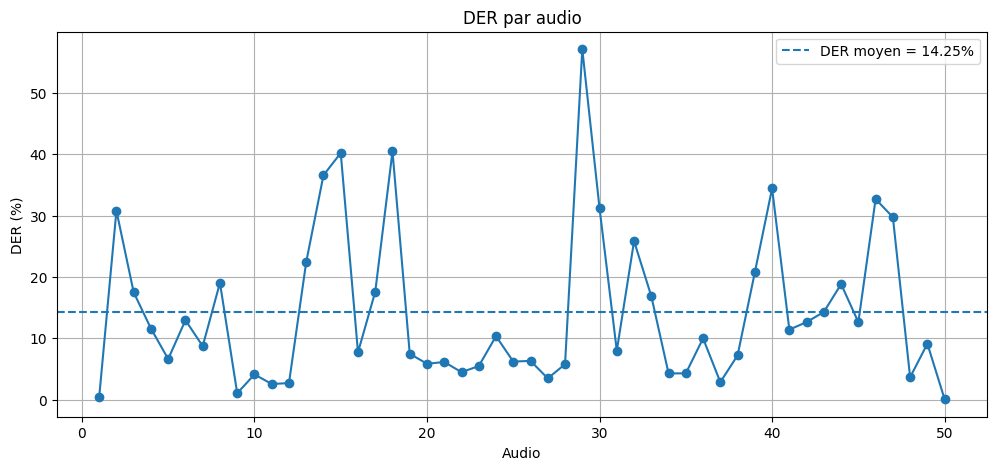

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

mean_der = np.mean(all_ders)

plt.figure(figsize=(12, 5))

plt.plot(
    range(1, len(all_ders) + 1),
    all_ders,
    marker="o"
)

plt.axhline(
    mean_der,
    linestyle="--",
    label=f"DER moyen = {mean_der:.2f}%"
)

plt.xlabel("Audio")
plt.ylabel("DER (%)")
plt.title("DER par audio")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
oireoire

## 10- Analyse des résultats

In [ ]:
import numpy as np
import IPython.display as ipd

# =====================================
# Meilleur audio
# =====================================

best_idx = np.argmin(all_ders)

print("=" * 60)
print("🏆 MEILLEUR AUDIO")
print("=" * 60)

print(f"Index : {best_idx}")
print(f"Fichier : {converted_files[best_idx]}")
print(f"DER : {all_ders[best_idx]:.2f}%")

display(
    ipd.Audio(
        audio_data[best_idx]["audio"],
        rate=audio_data[best_idx]["sr"]
    )
)

# =====================================
# Pire audio
# =====================================

worst_idx = np.argmax(all_ders)

print("\n" + "=" * 60)
print("💥 PIRE AUDIO")
print("=" * 60)

print(f"Index : {worst_idx}")
print(f"Fichier : {converted_files[worst_idx]}")
print(f"DER : {all_ders[worst_idx]:.2f}%")

display(
    ipd.Audio(
        audio_data[worst_idx]["audio"],
        rate=audio_data[worst_idx]["sr"]
    )
)

Output hidden; open in https://colab.research.google.com to view.

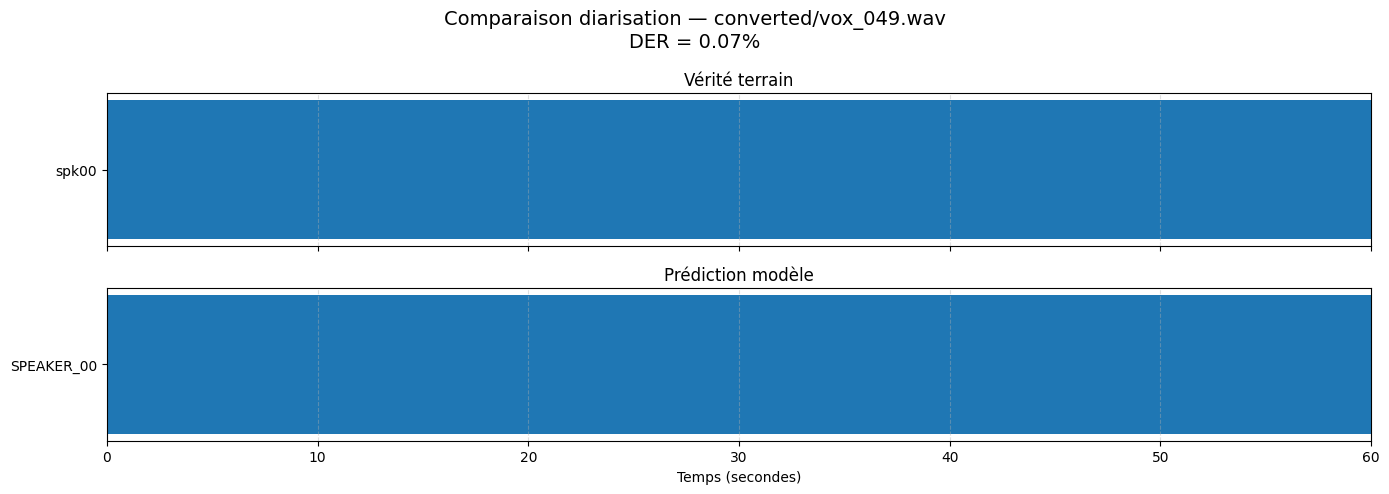

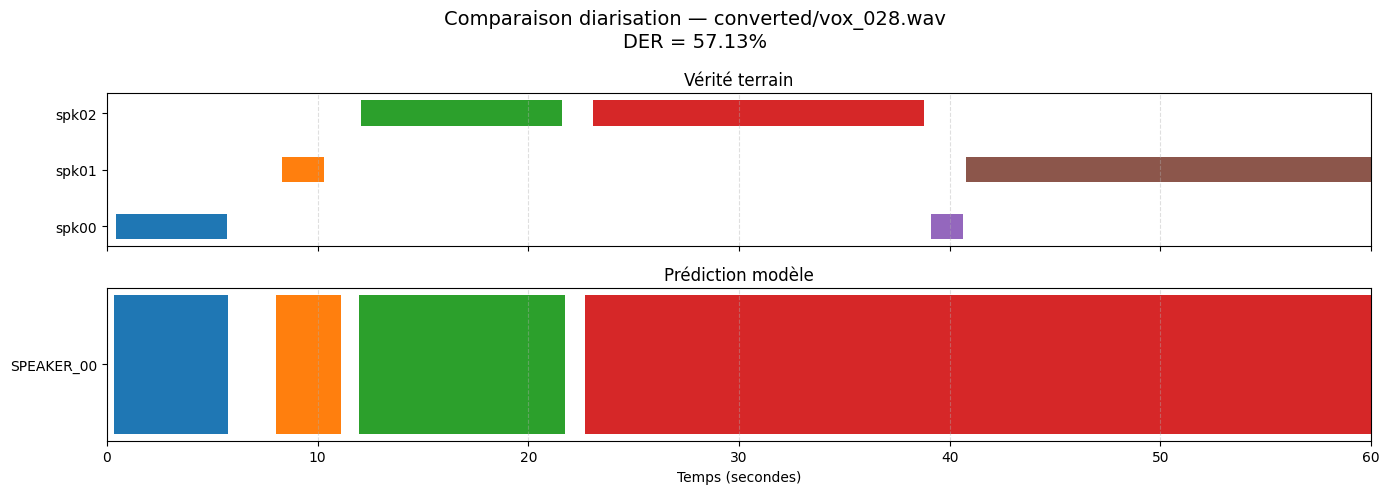

In [ ]:
import matplotlib.pyplot as plt

def plot_comparison(audio_idx):
    audio_path = converted_files[audio_idx]
    sample = audio_data[audio_idx]["sample"]

    # =========================
    # Vérité terrain
    # =========================

    gt_segments = []

    for start, end, speaker in zip(
        sample["timestamps_start"],
        sample["timestamps_end"],
        sample["speakers"]
    ):
        if start >= MAX_DURATION:
            continue

        gt_segments.append({
            "start": start,
            "end": min(end, MAX_DURATION),
            "speaker": str(speaker)
        })

    # =========================
    # Prédiction modèle
    # =========================

    pred_segments = all_results[audio_path]["segments"]

    # =========================
    # Affichage
    # =========================

    fig, axes = plt.subplots(
        2, 1,
        figsize=(14, 5),
        sharex=True
    )

    fig.suptitle(
        f"Comparaison diarisation — {audio_path}\nDER = {all_ders[audio_idx]:.2f}%",
        fontsize=14
    )

    def draw_segments(ax, segments, title):
        speakers = sorted(set(seg["speaker"] for seg in segments))
        speaker_to_y = {
            speaker: i
            for i, speaker in enumerate(speakers)
        }

        for seg in segments:
            y = speaker_to_y[seg["speaker"]]
            ax.barh(
                y=y,
                width=seg["end"] - seg["start"],
                left=seg["start"],
                height=0.45
            )

        ax.set_yticks(list(speaker_to_y.values()))
        ax.set_yticklabels(list(speaker_to_y.keys()))
        ax.set_title(title)
        ax.set_xlim(0, MAX_DURATION)
        ax.grid(axis="x", linestyle="--", alpha=0.4)

    draw_segments(
        axes[0],
        gt_segments,
        "Vérité terrain"
    )

    draw_segments(
        axes[1],
        pred_segments,
        "Prédiction modèle"
    )

    axes[1].set_xlabel("Temps (secondes)")

    plt.tight_layout()
    plt.show()


# Afficher meilleur et pire audio
plot_comparison(best_idx)
plot_comparison(worst_idx)